In [6]:
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import load_wine, fetch_openml
import pandas as pd
from drd import DRD# stored in base

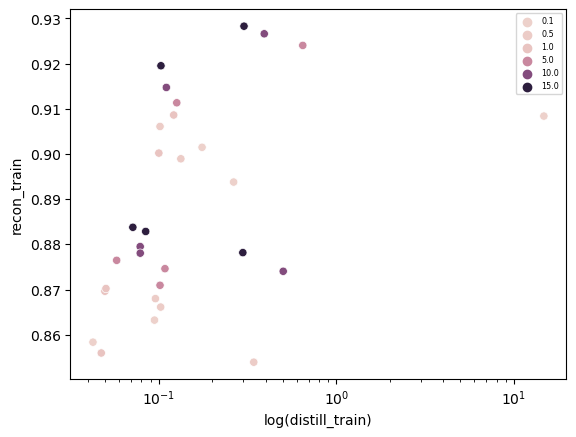

In [17]:
# plotting 
df = pd.read_csv('results/single_cell_umap_drd_joint_p_0.5p_0.1p.csv')
df = df[df.teacher_method != "pca"]
drd = df[df.student_method == "drd"].copy()
metrics = ["distill_test", "recon_test", "distill_train", "recon_train"]
sns.scatterplot(data = drd, x = 'distill_train', y = 'recon_train', marker='o', hue='lambda_d')
plt.xscale('log')
plt.xlabel('log(distill_train)')
plt.legend(fontsize='xx-small')

# Week Jun 23

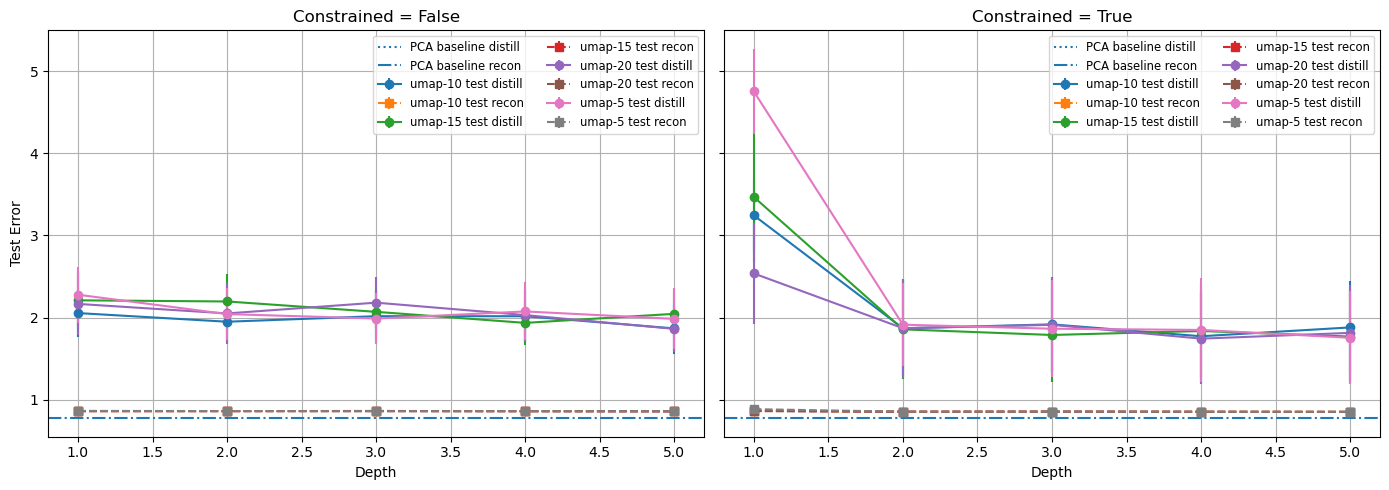

In [28]:
# 1) Load & filter
df_unconstrained = pd.read_csv("results/single_cell_umap_drd_lambda_d=0.5_joint_unconstrained.csv")
df_unconstrained = df_unconstrained[df_unconstrained.teacher_method != "pca"]
df_constrained = pd.read_csv("results/single_cell_umap_drd_lambda_d=0.5_joint_constrained.csv")
df_constrained = df_constrained[df_constrained.teacher_method != "pca"]
df = pd.concat([df_unconstrained, df_constrained], ignore_index=True)

# 2) Compute PCA baselines (over all seeds)
pca_df = df[df.student_method == "pca"]
baseline_distill = pca_df.distill_test.mean()
baseline_recon   = pca_df.recon_test.mean()

# 3) Prepare DRD data and teacher_id
drd = df[df.student_method == "drd"].copy()
drd["teacher_id"] = drd.teacher_method + "-" + drd.n_neighbors.astype(int).astype(str)

# 4) Aggregate over seeds
metrics = ["distill_test", "recon_test", "distill_train", "recon_train"]
agg = (
    drd
    .groupby(["constrained", "teacher_id", "depth"])[metrics]
    .agg(["mean", "std", "count"])
    .reset_index()
)
for m in metrics:
    agg[(m, "sem")] = agg[(m, "std")] / np.sqrt(agg[(m, "count")])

# 5) Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, constrained_flag in zip(axes, [False, True]):
    sub = agg[agg.constrained == constrained_flag]
    for (teacher_id), grp in sub.groupby("teacher_id"):
        # Distillation line
        ax.errorbar(
            grp.depth, grp[( "distill_test", "mean")],
            yerr=grp[( "distill_test", "sem")],
            marker="o", linestyle="-",
            label=f"{teacher_id} test distill"
        )
        # Reconstruction line
        ax.errorbar(
            grp.depth, grp[( "recon_test", "mean")],
            yerr=grp[( "recon_test", "sem")],
            marker="s", linestyle="--",
            label=f"{teacher_id} test recon"
        )
    # Add PCA baseline lines
    ax.axhline(baseline_distill, linestyle=":", label="PCA baseline distill")
    ax.axhline(baseline_recon,   linestyle="-.", label="PCA baseline recon")

    ax.set_title(f"Constrained = {constrained_flag}")
    ax.set_xlabel("Depth")
    if not constrained_flag:
        ax.set_ylabel("Test Error")
    ax.grid(True)
    ax.legend(fontsize="small", ncol=2)

plt.tight_layout()
plt.show()


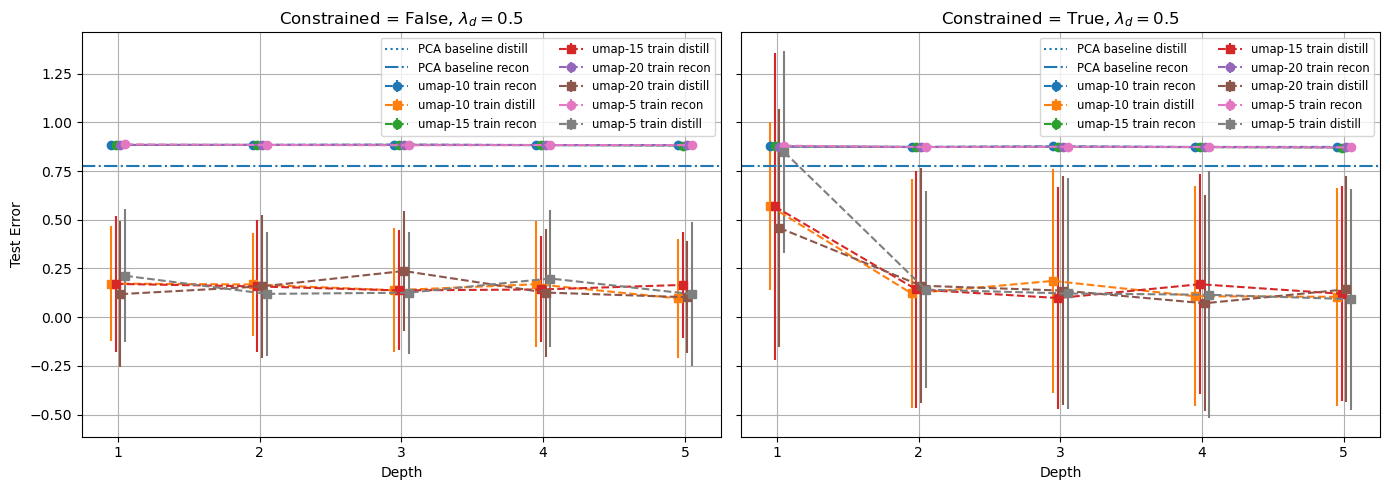

In [11]:
# 1) Load & filter
df_unconstrained = pd.read_csv("results/single_cell_umap_drd_lambda_d=0.5_joint_unconstrained.csv")
df_unconstrained = df_unconstrained[df_unconstrained.teacher_method != "pca"]
df_constrained = pd.read_csv("results/single_cell_umap_drd_lambda_d=0.5_joint_constrained.csv")
df_constrained = df_constrained[df_constrained.teacher_method != "pca"]
df = pd.concat([df_unconstrained, df_constrained], ignore_index=True)

# 2) Compute PCA baselines (over all seeds)
pca_df = df[df.student_method == "pca"]
baseline_distill = pca_df.distill_test.mean()
baseline_recon   = pca_df.recon_test.mean()

# 3) Prepare DRD data and teacher_id
drd = df[df.student_method == "drd"].copy()
drd["teacher_id"] = drd.teacher_method + "-" + drd.n_neighbors.astype(int).astype(str)

# 4) Aggregate over seeds
metrics = ["distill_test", "recon_test", "distill_train", "recon_train"]
agg = (
    drd
    .groupby(["constrained", "teacher_id", "depth"])[metrics]
    .agg(["mean", "std", "count"])
    .reset_index()
)
for m in metrics:
    agg[(m, "sem")] = agg[(m, "std")] / np.sqrt(agg[(m, "count")])

# 5) Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

max_jitter = 0.05

for ax, constrained_flag in zip(axes, [False, True]):
    sub = agg[agg.constrained == constrained_flag]
    teachers = sorted(sub.teacher_id.unique())
    # create offsets evenly spaced in [–max_jitter, +max_jitter]
    offsets = {
        tid: np.linspace(-max_jitter, max_jitter, len(teachers))[i]
        for i, tid in enumerate(teachers)
    }
    for (teacher_id), grp in sub.groupby("teacher_id"):
        # Distillation line
        x_j = grp.depth + offsets[teacher_id]
        ax.errorbar(
            x_j, grp[( "recon_train", "mean")],
            yerr=grp[( "recon_train", "sem")],
            marker="o", linestyle="--",
            label=f"{teacher_id} train recon"
        )
        ax.errorbar(
            x_j, grp[( "distill_train", "mean")],
            yerr=grp[( "distill_test", "sem")],
            marker="s", linestyle="--",
            label=f"{teacher_id} train distill"
        )
    # Add PCA baseline lines
    ax.axhline(baseline_distill, linestyle=":", label="PCA baseline distill")
    ax.axhline(baseline_recon,   linestyle="-.", label="PCA baseline recon")

    ax.set_title(f"Constrained = {constrained_flag}, $\lambda_d=0.5$")
    ax.set_xlabel("Depth")
    if not constrained_flag:
        ax.set_ylabel("Test Error")
    ax.grid(True)
    ax.legend(fontsize="small", ncol=2)

plt.tight_layout()
plt.show()


In [34]:
import pandas as pd
import numpy as np

# 1) Load & (optionally) filter
df_unconstrained = pd.read_csv("results/single_cell_umap_drd_lambda_d=0.5_joint_unconstrained.csv")
df_unconstrained = df_unconstrained[df_unconstrained.teacher_method != "pca"]
df_constrained = pd.read_csv("results/single_cell_umap_drd_lambda_d=0.5_joint_constrained.csv")
df_constrained = df_constrained[df_constrained.teacher_method != "pca"]
df = pd.concat([df_unconstrained, df_constrained], ignore_index=True)

# 2) Create a concise teacher ID (e.g. "umap-5", "pca-0")
df['teacher_id'] = (
    df['teacher_method']
      .fillna('pca')                     # pca entries have no teacher_method/n_neighbors
      + '-' 
      + df['n_neighbors'].fillna(0)
          .astype(int)
          .astype(str)
)

# 3) Choose grouping keys & metrics
group_cols = ['teacher_id', 'student_method', 'depth', 'constrained', 'symmetric', 'optimize']
metrics   = ['distill_train', 'recon_train', 'distill_test', 'recon_test']

# 4) Aggregate: mean, std, count → then compute SEM
agg = df.groupby(group_cols)[metrics].agg(['mean', 'std', 'count'])
# flatten MultiIndex columns
agg.columns = ['_'.join(col) for col in agg.columns]
agg['distill_train_sem'] = agg['distill_train_std'] / np.sqrt(agg['distill_train_count'])
agg['recon_train_sem']   = agg['recon_train_std']   / np.sqrt(agg['recon_train_count'])
agg['distill_test_sem'] = agg['distill_test_std'] / np.sqrt(agg['distill_test_count'])
agg['recon_test_sem']   = agg['recon_test_std']   / np.sqrt(agg['recon_test_count'])

# 5) Reset index and pick only the summary columns you need
summary = agg.reset_index()[[
    'teacher_id','depth','constrained',
    'distill_train_mean','distill_train_sem',
    'recon_train_mean',  'recon_train_sem',
    'distill_test_mean', 'distill_test_sem',
    'recon_test_mean',   'recon_test_sem'
]]
summary = summary.round(3)
# 6) Display or save
print(summary.to_string(index=False))
# — or —
summary.to_csv("train_summary_table_joint_constrained.csv", index=False)


teacher_id  depth  constrained  distill_train_mean  distill_train_sem  recon_train_mean  recon_train_sem  distill_test_mean  distill_test_sem  recon_test_mean  recon_test_sem
   umap-10    1.0        False               0.172              0.028             0.884            0.009              2.054             0.293            0.860           0.005
   umap-10    1.0         True               0.571              0.202             0.876            0.009              3.243             0.432            0.866           0.008
   umap-10    2.0        False               0.168              0.028             0.884            0.008              1.949             0.263            0.861           0.005
   umap-10    2.0         True               0.122              0.018             0.874            0.009              1.869             0.587            0.853           0.004
   umap-10    3.0        False               0.138              0.032             0.885            0.009              2.016  